In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [2]:
(X_train, Y_train), (x_test, y_test)=keras.datasets.imdb.load_data(num_words=10000)

In [12]:
print(X_train.dtype)
print(x_test.dtype)

int32
int32


In [13]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

X_train = pad_sequences(X_train, maxlen=300)
X_test  = pad_sequences(X_test, maxlen=300)

X_train = np.asarray(X_train, dtype=np.int32)
X_test  = np.asarray(X_test, dtype=np.int32)

y_train = np.asarray(y_train, dtype=np.float32)
y_test  = np.asarray(y_test, dtype=np.float32)

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train=pad_sequences(X_train,maxlen=300)
x_test = pad_sequences(x_test,maxlen=300)

In [4]:
print(X_train.shape)

(25000, 300)


In [14]:
model = keras.Sequential([
    keras.layers.Embedding(
        input_dim = 10000,
        output_dim =128,
        input_length = 300
    ),
    keras.layers.LSTM(
        128,
        return_sequences =True
        ),
    keras.layers.LSTM(
        32,
        dropout = 0.3,
        recurrent_dropout =0.3
    ),


    keras.layers.Dense(32,activation = 'relu'),

    keras.layers.Dense(1,activation= 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
model.compile(
    optimizer='adam',
    loss ='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor ='val_loss',
    patience=2,
    restore_best_weights = True
)

In [16]:
history = model.fit(
    X_train,
    Y_train,
    epochs = 5,
    batch_size = 128,
    validation_data = (x_test, y_test),
    callbacks = [early_stop],


)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.6751 - loss: 0.5834 - val_accuracy: 0.8354 - val_loss: 0.3965
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.8805 - loss: 0.3012 - val_accuracy: 0.8716 - val_loss: 0.3100
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.9199 - loss: 0.2147 - val_accuracy: 0.8695 - val_loss: 0.3119
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.9415 - loss: 0.1635 - val_accuracy: 0.8425 - val_loss: 0.3581


In [17]:
model.evaluate(x_test,y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step - accuracy: 0.8705 - loss: 0.3140


[0.3099976181983948, 0.8715999722480774]

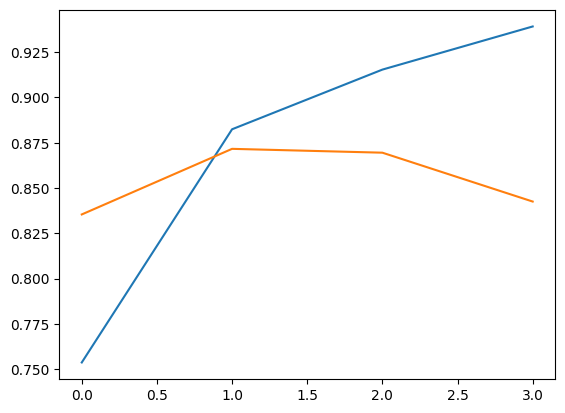

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [19]:
pred= model.predict(x_test[:1])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
[[0.19950145]]


In [20]:
import numpy as np
predicted_class = np.argmax(pred)
print(predicted_class)

0


In [21]:
print("actuall:",y_test[0])
print("predicted:",predicted_class)

actuall: 0.0
predicted: 0


In [22]:
model.save("RNN_model.h5")